# Machine Learning Foundations

This notebook explores regression, regularization, optimization, dimensionality reduction, and model evaluation on benchmark datasets.

## Topics covered
- linear regression with gradient descent
- Ridge regression and optimization comparisons
- PCA and LDA for dimensionality reduction
- KNN evaluation after feature transformation


## Regression and Optimization

### Linear regression with batch gradient descent
Implement linear regression using mean squared error minimization and full-batch gradient descent.

Requirements:
- Minimize the Mean Squared Error (MSE) loss function: $L(\theta)=\frac{1}{2m} \sum_{i=1}^m (h_\theta(x^{(i)})-y^{(i)})^2$ where $h_\theta(x)= \mathbf{X} \theta$
 is the prediction and  $m$ is the number of samples. The factor of $\frac{1}{2}$ simplifies the gradient calculation.
- Initialize all weights to zero
- Use gradient descent (use all samples in each iteration).
The input matrix X has shape $(m, n)$ where $m$ is the number of training examples and $n$ is the number of features (including the bias column of ones). The target vector y has shape $(m,)$.

In [ ]:
# Implementation
import jax.numpy as jnp
import numpy as np
def linear_regression_gradient_descent(X: jnp.ndarray, y: jnp.ndarray, alpha: float, iterations: int) -> np.ndarray:
	print(y)
	m, n = X.shape
	theta = jnp.zeros((n,), dtype=X.dtype)

	for _ in range(iterations):
		preds = jnp.dot(X, theta)
		error = preds - y
		gradient = jnp.dot(X.T, error) / m
		theta -= alpha * gradient

	return theta

### Ridge regression loss function
Implement the Ridge objective that combines mean squared error with L2 regularization.

Example:

Input:
```
import numpy as np

X = np.array([[1, 1], [2, 1], [3, 1], [4, 1]])
w = np.array([0.2, 2])
y_true = np.array([2, 3, 4, 5])
alpha = 0.1

loss = ridge_loss(w, X, y_true, alpha)
print(loss)
```
Output:

```
2.204
```

In [ ]:
# Implementation
import jax.numpy as jnp

def ridge_loss(w: jnp.ndarray,
               X: jnp.ndarray,
               y_true: jnp.ndarray,
               alpha: float) -> float:
    """
    Ridge loss:
    L(w) = (1/(2m)) * ||Xw - y||^2 + alpha * ||w||^2
    """

    m = X.shape[0]

    # Predictions
    y_pred = X @ w

    # Mean Squared Error term
    mse = (1 / (2 * m)) * jnp.sum((y_pred - y_true) ** 2)

    # Regularization term
    reg = alpha * jnp.sum(w ** 2)

    return mse + reg

### Comparing Ridge optimization approaches on MNIST
Compare mini-batch SGD, the closed-form Ridge solution, and unregularized linear regression for binary classification on MNIST digits 1 vs 7. Use the objective function from 
2. Apply the closed-form solution of Ridge regression as well as the linear regression method from  on the binary classification task of digits ('1' and '7') in MNIST.
3. Compare the results from .1 and .2 in terms of convergence rate and classification accuracy.

In [ ]:
# =========================
# Full implementation
# Digits: '1' vs '7' in MNIST
# Models:
# 1) Ridge mini-batch SGD (autograd), batch_size=55
# 2) Ridge closed-form
# 3) Linear regression batch GD (Part 1.1 style) on same task

# install python_mnist

!pip install python_mnist

import numpy as np
import jax.numpy as jnp
from jax import grad
from mnist import MNIST


# -------------------------
# 0) Load + prepare MNIST
# -------------------------
def load_mnist_1_vs_7(mnist_path="MNIST", noise_std=1e-4):
    mnist_loader = MNIST(mnist_path)
    train_data, train_label = mnist_loader.load_training()
    test_data, test_label = mnist_loader.load_testing()

    train_data = np.array(train_data, dtype=np.float32) / 255.0
    test_data  = np.array(test_data,  dtype=np.float32) / 255.0
    train_label = np.array(train_label, dtype=np.int16)
    test_label  = np.array(test_label,  dtype=np.int16)

    # Add small noise to avoid singularities in closed-form computations
    train_data += np.random.normal(0.0, noise_std, train_data.shape).astype(np.float32)

    # Filter digits 1 and 7
    idx_tr = np.logical_or(train_label == 1, train_label == 7)
    idx_te = np.logical_or(test_label == 1, test_label == 7)

    X_train = train_data[idx_tr]
    y_train = train_label[idx_tr]
    X_test  = test_data[idx_te]
    y_test  = test_label[idx_te]

    # Add bias column of ones (at the END, same as your earlier code)
    X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1), dtype=X_train.dtype)))
    X_test  = np.hstack((X_test,  np.ones((X_test.shape[0],  1), dtype=X_test.dtype)))

    # Convert labels to -1/+1 using sign(label - cutoff)
    # Any cutoff between 1 and 7 works. Use 4.
    CUTOFF = 4
    y_train = np.sign(y_train - CUTOFF).astype(np.float32)   # 1 -> -1, 7 -> +1
    y_test  = np.sign(y_test  - CUTOFF).astype(np.float32)

    return X_train, y_train, X_test, y_test


# -------------------------
# 1) Utilities: accuracy/MSE
# -------------------------
def mse_numpy(pred, y):
    return float(np.sum((pred - y) ** 2) / pred.shape[0])

def acc_sign_numpy(scores, y):
    pred = np.sign(scores)
    return float(np.count_nonzero(pred == y) / y.size)

def print_eval(title, w, X_train, y_train, X_test, y_test):
    # Train
    pred_tr = X_train @ w
    print(f"\n[{title}]")
    print(f"mean square error (train): {mse_numpy(pred_tr, y_train):.5f}")
    print(f"classification accuracy (train): {acc_sign_numpy(pred_tr, y_train)*100.0:.2f}%")

    # Test
    pred_te = X_test @ w
    print(f"mean square error (test):  {mse_numpy(pred_te, y_test):.5f}")
    print(f"classification accuracy (test):  {acc_sign_numpy(pred_te, y_test)*100.0:.2f}%")


# -------------------------
# 2) Optimizer class
# -------------------------
class Optimizer:
    def __init__(self, lr, annealing_rate, batch_size, max_epochs):
        self.lr = lr
        self.annealing_rate = annealing_rate
        self.batch_size = batch_size
        self.max_epochs = max_epochs


# ============================================================
# 1.3.1 Ridge Regression: mini-batch SGD + autograd (batch=55)
# Objective from Part 1.2:
#   L(w) = (1/(2m)) * ||Xw - y||^2 + alpha * ||w||^2
# ============================================================
def ridge_obj_func(w, X, y, alpha):
    diff = X @ w - y
    mse = jnp.sum(diff * diff) / (2.0 * X.shape[0])
    reg = alpha * jnp.sum(w * w)
    return mse + reg

def ridge_regression_sgd_autograd(X, y, X2, y2, op, alpha):
    """
    Returns:
      w, errorsA, errorsB, errorsC
    where:
      errorsA = train accuracy per epoch
      errorsB = test accuracy per epoch
      errorsC = train ridge loss per epoch
    """
    # Convert to jax arrays once
    Xj  = jnp.array(X, dtype=jnp.float32)
    yj  = jnp.array(y, dtype=jnp.float32)
    X2j = jnp.array(X2, dtype=jnp.float32)
    y2j = jnp.array(y2, dtype=jnp.float32)

    n = Xj.shape[0]
    w = jnp.zeros(Xj.shape[1], dtype=jnp.float32)  # init zeros

    lr = op.lr
    errorsA = np.zeros(op.max_epochs)
    errorsB = np.zeros(op.max_epochs)
    errorsC = np.zeros(op.max_epochs)

    for epoch in range(op.max_epochs):
        indices = np.random.permutation(n)

        for batch_start in range(0, n, op.batch_size):
            batch_idx = indices[batch_start:batch_start + op.batch_size]
            Xb = Xj[batch_idx]
            yb = yj[batch_idx]

            # autograd gradient
            g = grad(ridge_obj_func)(w, Xb, yb, alpha)

            # IMPORTANT: ridge_obj_func already divides by (2*batch_size),
            w = w - lr * g

        # Learning curve C: ridge loss on full train set
        errorsC[epoch] = float(ridge_obj_func(w, Xj, yj, alpha))

        # Learning curve A/B: accuracy on train/test
        pred_tr = np.sign(np.array(Xj @ w))
        errorsA[epoch] = np.count_nonzero(pred_tr == y) / y.size

        pred_te = np.sign(np.array(X2j @ w))
        errorsB[epoch] = np.count_nonzero(pred_te == y2) / y2.size

        lr *= op.annealing_rate
        print(f"epoch={epoch}: ridge_loss={errorsC[epoch]:.4f} (train_acc={errorsA[epoch]:.4f}, test_acc={errorsB[epoch]:.4f})")

    return np.array(w), errorsA, errorsB, errorsC


# ==========================================
# 2) Ridge Regression: closed-form solution
# From Part 1.2 objective:
#   (1/(2m))||Xw-y||^2 + alpha||w||^2
# => (X^T X + 2*alpha*m*I) w = X^T y
# ==========================================
def ridge_closed_form(X, y, alpha, regularize_bias=True):
    m, d = X.shape
    I = np.eye(d, dtype=X.dtype)

    # Your bias column is last (because you hstack ones at the end)
    if not regularize_bias:
        I[-1, -1] = 0.0

    A = X.T @ X + (2.0 * alpha * m) * I
    b = X.T @ y
    w = np.linalg.solve(A, b)
    return w


# ==========================================
# 3) Linear regression (Part 1.1 style):
# batch gradient descent minimizing MSE only
# L(w) = (1/(2m))||Xw-y||^2
# ==========================================
def mse_obj_func(w, X, y):
    diff = X @ w - y
    return jnp.sum(diff * diff) / (2.0 * X.shape[0])

def linear_regression_batch_gd(X, y, X2, y2, op):
    """
    One full-batch update per epoch.
    Returns:
      w, errorsA, errorsB, errorsC  (accuracy train/test, mse train)
    """
    Xj  = jnp.array(X, dtype=jnp.float32)
    yj  = jnp.array(y, dtype=jnp.float32)
    X2j = jnp.array(X2, dtype=jnp.float32)
    y2j = jnp.array(y2, dtype=jnp.float32)

    w = jnp.zeros(Xj.shape[1], dtype=jnp.float32)

    lr = op.lr
    errorsA = np.zeros(op.max_epochs)
    errorsB = np.zeros(op.max_epochs)
    errorsC = np.zeros(op.max_epochs)

    for epoch in range(op.max_epochs):
        g = grad(mse_obj_func)(w, Xj, yj)
        w = w - lr * g

        errorsC[epoch] = float(mse_obj_func(w, Xj, yj))

        pred_tr = np.sign(np.array(Xj @ w))
        errorsA[epoch] = np.count_nonzero(pred_tr == y) / y.size

        pred_te = np.sign(np.array(X2j @ w))
        errorsB[epoch] = np.count_nonzero(pred_te == y2) / y2.size

        lr *= op.annealing_rate
        print(f"epoch={epoch}: mse={errorsC[epoch]:.4f} (train_acc={errorsA[epoch]:.4f}, test_acc={errorsB[epoch]:.4f})")

    return np.array(w), errorsA, errorsB, errorsC


# -------------------------
# 3) Run everything + compare
# -------------------------
if __name__ == "__main__":
    X_train, y_train, X_test, y_test = load_mnist_1_vs_7(mnist_path="MNIST", noise_std=1e-4)
    print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

    alpha_ridge = 0.1

    # ---- 1.3.2 Closed-form ridge ----
    w_cf = ridge_closed_form(X_train, y_train, alpha=alpha_ridge, regularize_bias=True)
    print_eval("1.3.2 Closed-form Ridge", w_cf, X_train, y_train, X_test, y_test)

    # ---- 1.3.1 Mini-batch SGD ridge (autograd), batch_size=55 ----
    op_sgd = Optimizer(lr=0.05, annealing_rate=0.99, batch_size=55, max_epochs=20)
    w_sgd, A1, B1, C1 = ridge_regression_sgd_autograd(X_train, y_train, X_test, y_test, op_sgd, alpha=alpha_ridge)
    print_eval("1.3.1 Ridge mini-batch SGD", w_sgd, X_train, y_train, X_test, y_test)

    # ---- 1.3.3 Linear regression batch GD (Part 1.1 style), no ridge ----
    op_gd = Optimizer(lr=0.05, annealing_rate=0.99, batch_size=X_train.shape[0], max_epochs=200)
    w_gd, A3, B3, C3 = linear_regression_batch_gd(X_train, y_train, X_test, y_test, op_gd)
    print_eval("1.3.3 Linear regression batch GD (MSE)", w_gd, X_train, y_train, X_test, y_test)

    # ---- Simple comparison summary ----
    print("\n===== Comparison (Convergence + Accuracy) =====")
    print(f"Closed-form Ridge:    test_acc = {acc_sign_numpy(X_test @ w_cf,  y_test)*100.0:.2f}%  (instant solve)")
    print(f"SGD Ridge (epoch end): test_acc = {acc_sign_numpy(X_test @ w_sgd, y_test)*100.0:.2f}%  (loss curve in C1)")
    print(f"Batch GD (epoch end):  test_acc = {acc_sign_numpy(X_test @ w_gd,  y_test)*100.0:.2f}%  (loss curve in C3)")

Shapes: (13007, 785) (13007,) (2163, 785) (2163,)

[1.3.2 Closed-form Ridge]
mean square error (train): 0.08807
classification accuracy (train): 98.80%
mean square error (test):  0.08957
classification accuracy (test):  98.38%
epoch=0: ridge_loss=0.0730 (train_acc=0.9811, test_acc=0.9769)
epoch=1: ridge_loss=0.0775 (train_acc=0.9912, test_acc=0.9908)
epoch=2: ridge_loss=0.0694 (train_acc=0.9896, test_acc=0.9871)
epoch=3: ridge_loss=0.0636 (train_acc=0.9872, test_acc=0.9847)
epoch=4: ridge_loss=0.0688 (train_acc=0.9835, test_acc=0.9792)
epoch=5: ridge_loss=0.0641 (train_acc=0.9892, test_acc=0.9875)
epoch=6: ridge_loss=0.0634 (train_acc=0.9879, test_acc=0.9838)
epoch=7: ridge_loss=0.0634 (train_acc=0.9886, test_acc=0.9847)
epoch=8: ridge_loss=0.0720 (train_acc=0.9902, test_acc=0.9880)
epoch=9: ridge_loss=0.0770 (train_acc=0.9803, test_acc=0.9741)
epoch=10: ridge_loss=0.0647 (train_acc=0.9882, test_acc=0.9834)
epoch=11: ridge_loss=0.0710 (train_acc=0.9906, test_acc=0.9903)
epoch=12: ridge

## Dimensionality Reduction and Classification
In this question, use the sklearn library.

### Data preparation
Load the breast cancer dataset, split it into train and test sets, and standardize the features.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X_bc = data.data
y_bc = data.target

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=2, stratify=y_bc
)

scaler_bc = StandardScaler()
X_train_scaled_bc = scaler_bc.fit_transform(X_train_bc)
X_test_scaled_bc = scaler_bc.transform(X_test_bc)

print("X_train_scaled_bc:", X_train_scaled_bc.shape)
print("y_train_bc:", y_train_bc.shape)
print("X_test_scaled_bc:", X_test_scaled_bc.shape)
print("y_test_bc:", y_test_bc.shape)

X_train_scaled_bc: (455, 30)
y_train_bc: (455,)
X_test_scaled_bc: (114, 30)
y_test_bc: (114,)


### PCA analysis
Fit PCA on the training data, inspect explained variance, and choose the number of components that preserve at least 95% of the variance.

Explained variance ratio per component:
    PC1: 0.43
    PC2: 0.20
    PC3: 0.09
    PC4: 0.07
    PC5: 0.06
    PC6: 0.04
    PC7: 0.02
    PC8: 0.02
    PC9: 0.01
    PC10: 0.01
    PC11: 0.01
    PC12: 0.01
    PC13: 0.01
    PC14: 0.01
    PC15: 0.00
    PC16: 0.00
    PC17: 0.00
    PC18: 0.00
    PC19: 0.00
    PC20: 0.00
    PC21: 0.00
    PC22: 0.00
    PC23: 0.00
    PC24: 0.00
    PC25: 0.00
    PC26: 0.00
    PC27: 0.00
    PC28: 0.00
    PC29: 0.00
    PC30: 0.00


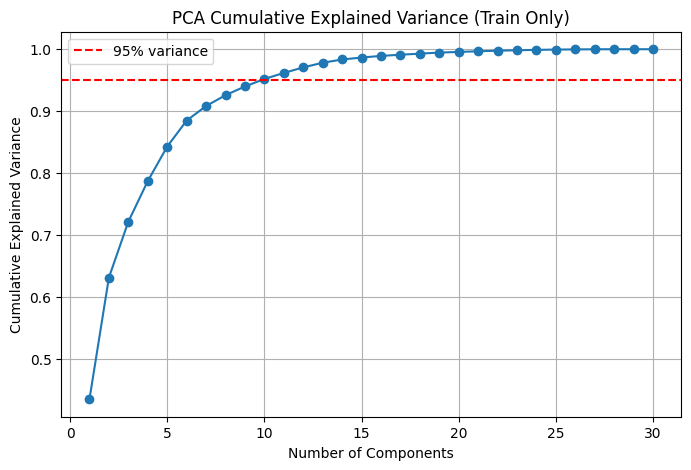


Number of components to retain at least 95% variance: 10

New shapes after PCA transformation:
Training set: (455, 10)
Testing set: (114, 10)


In [ ]:
# Implementation
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Fit PCA on training data only
pca = PCA()
pca.fit(X_train_scaled_bc)

print("Explained variance ratio per component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"    PC{i+1}: {ratio:.2f}")

# Cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance (Train Only)")
plt.legend()
plt.grid(True)
plt.show()

# Choose smallest #components to reach >=95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components to retain at least 95% variance: {n_components_95}")

# Fit PCA with chosen components on train only, transform both
pca_95 = PCA(n_components=n_components_95)
X_train_pca_bc = pca_95.fit_transform(X_train_scaled_bc)
X_test_pca_bc  = pca_95.transform(X_test_scaled_bc)

print("\nNew shapes after PCA transformation:")
print("Training set:", X_train_pca_bc.shape)
print("Testing set:", X_test_pca_bc.shape)

### LDA projection
Fit LDA, reduce to the maximum valid dimensionality, and compare class separation with a PCA-based 2D projection.

LDA components: 1
X_train_lda shape: (455, 1)
X_test_lda shape: (114, 1)


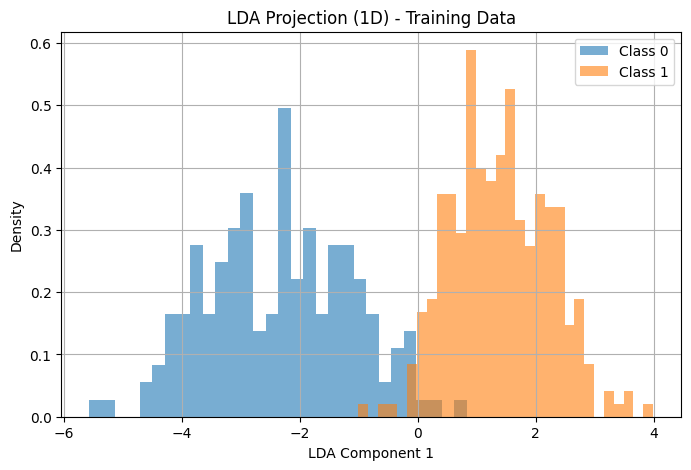

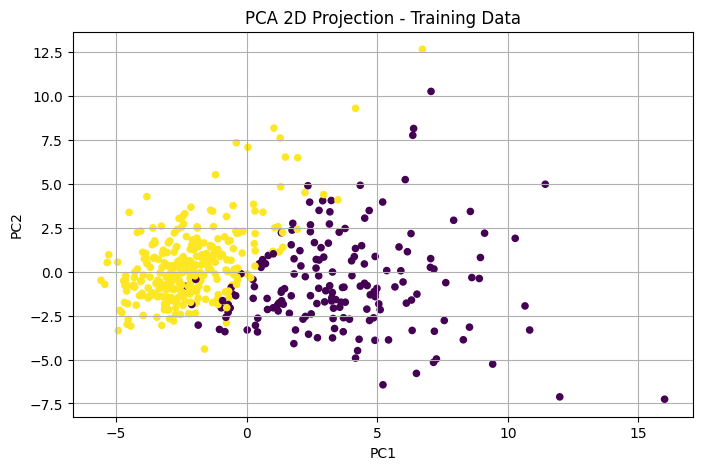

In [ ]:
# Implementation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA

# 1) Fit LDA (training data only), reduce to max possible components
n_classes = len(np.unique(y_train_bc))
n_lda_components = n_classes - 1  # for 2 classes => 1

lda = LinearDiscriminantAnalysis(n_components=n_lda_components)
X_train_lda_bc = lda.fit_transform(X_train_scaled_bc, y_train_bc)
X_test_lda_bc  = lda.transform(X_test_scaled_bc)

print("LDA components:", n_lda_components)
print("X_train_lda shape:", X_train_lda_bc.shape)
print("X_test_lda shape:", X_test_lda_bc.shape)

# 2) Visualize LDA transformed data (1D projection)
plt.figure(figsize=(8,5))
for cls in np.unique(y_train_bc):
    plt.hist(
        X_train_lda_bc[y_train_bc == cls, 0],
        bins=30,
        alpha=0.6,
        density=True,
        label=f"Class {cls}"
    )
plt.xlabel("LDA Component 1")
plt.ylabel("Density")
plt.title("LDA Projection (1D) - Training Data")
plt.legend()
plt.grid(True)
plt.show()

# 3) PCA 2D projection for comparison (fit on train only)
pca2 = PCA(n_components=2)
X_train_pca2_bc = pca2.fit_transform(X_train_scaled_bc)

plt.figure(figsize=(8,5))
plt.scatter(X_train_pca2_bc[:, 0], X_train_pca2_bc[:, 1], c=y_train_bc, s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection - Training Data")
plt.grid(True)
plt.show()

### KNN evaluation across feature spaces
Compare baseline KNN, PCA-transformed KNN, and LDA-transformed KNN using accuracy, runtime, and confusion matrices.

In [ ]:
# Implementation
# ============================
# KNN: Baseline vs PCA vs LDA
# ============================

import time
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

k = 5

def evaluate_model(name, model, Xtr, ytr, Xte, yte):
    start = time.perf_counter()

    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    elapsed = time.perf_counter() - start
    acc = accuracy_score(yte, y_pred)
    cm = confusion_matrix(yte, y_pred)

    print(f"\n===== {name} =====")
    print(f"Accuracy: {acc:.4f}")
    print(f"Running time (fit + predict): {elapsed:.6f} seconds")
    print("Confusion Matrix:")
    print(cm)

# 1) Baseline (KNN with no dimensionality reduction)
baseline_knn = KNeighborsClassifier(n_neighbors=k)
evaluate_model("Baseline (KNN, no DR)", baseline_knn,
               X_train_scaled_bc, y_train_bc, X_test_scaled_bc, y_test_bc)

# 2) PCA + Classifier (using components chosen in 2.2)
pca_knn = Pipeline([
    ("pca", PCA(n_components=n_components_95)),
    ("knn", KNeighborsClassifier(n_neighbors=k))
])
evaluate_model(f"PCA({n_components_95}) + KNN", pca_knn,
               X_train_scaled_bc, y_train_bc, X_test_scaled_bc, y_test_bc)

# 3) LDA + Classifier (max components = n_classes - 1; for breast cancer => 1)
lda_knn = Pipeline([
    ("lda", LinearDiscriminantAnalysis(n_components=1)),
    ("knn", KNeighborsClassifier(n_neighbors=k))
])
evaluate_model("LDA(1) + KNN", lda_knn,
               X_train_scaled_bc, y_train_bc, X_test_scaled_bc, y_test_bc)


===== Baseline (KNN, no DR) =====
Accuracy: 0.9825
Running time (fit + predict): 0.004923 seconds
Confusion Matrix:
[[40  2]
 [ 0 72]]

===== PCA(10) + KNN =====
Accuracy: 0.9825
Running time (fit + predict): 0.009308 seconds
Confusion Matrix:
[[40  2]
 [ 0 72]]

===== LDA(1) + KNN =====
Accuracy: 0.9737
Running time (fit + predict): 0.096635 seconds
Confusion Matrix:
[[40  2]
 [ 1 71]]
